# FLISM Lifetime Reconstruction Pipeline


### This Notebook's Operations

This workflow starts from `FILE_DATA`, creates a calibrated source file, then writes s2ISM and fit products into one exported pipeline file.

1. `FILE_DATA` -> calibration -> `FILE_WITH_CALIBRATION`
2. `FILE_WITH_CALIBRATION` -> `s2ism` with `mode="copy"` -> `EXPORT_PATH`
3. `EXPORT_PATH` -> `s2_lifetime_fit` with `mode="append"` -> same `EXPORT_PATH`

The exported file therefore contains the reconstructed decay and the s2 lifetime-fit products together under `/output`.

This notebook demonstrates the full analysis pipeline for **Fluorescence Lifetime Image Scanning Microscopy (FLISM)**, combining:

- **s²ISM** (separation-based ISM) reconstruction for improved spatial resolution
- **FLIM** (Fluorescence Lifetime Imaging Microscopy) analysis via per-pixel exponential fitting

The pipeline operates on raw TCSPC (Time-Correlated Single Photon Counting) data acquired with the BrightEyes multi-channel SPAD array detector, stored in the BrightEyes HDF5 format.


### Workflow overview

1. **Calibration** – Correct for per-channel timing offsets (channel skew) and instrument response using a reference dye of known lifetime.
2. **Data loading** – Read the calibrated data and auxiliary traces (IRF, reference) from the HDF5 file.
3. **IRF inspection & smoothing** – Visualise and optionally smooth the per-channel Impulse Response Functions.
4. **Spatial PSF simulation** – Simulate the expected spatial point-spread functions for the SPAD array geometry.
5. **s²ISM reconstruction** – Deconvolve the 4D (x, y, time, channel) dataset using a joint spatio-temporal kernel.
6. **Lifetime analysis** – Fit an IRF-convolved mono-exponential model to each pixel of the reconstructed image to derive per-pixel lifetime maps.

> **Note:**
    - **s²ISM** reconstruction with a `psf_delta` kernel — removes the spatial PSF only,
  leaving the IRF broadening intact in the output decay traces.
    - **Per-pixel fit** of an IRF-convolved mono-exponential model to each reconstructed pixel.

### Required packages

| Package | Role |
|---|---|
| `brighteyes_ism` | PSF simulation, ISM graph utilities, MCS I/O |
| `brighteyes_flim` | Lifetime visualisation |
| `brighteyes_mcs_file` | HDF5 calibration, data I/O and per-pixel fit engine |
| `s2ism` | s²ISM reconstruction engine and PSF estimator |
| `numpy`, `matplotlib` | Numerics and plotting |
| `h5py` | Low-level HDF5 access |
| `torch` | GPU-accelerated tensor operations (used for IRF smoothing) |


In [ ]:
FILE_REFERENCE = '/mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5'
FILE_DATA = '/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5'

DATA_KEY             = "data"   # "data" or "data_channels_extra"

# ── Calibration parameters ────────────────────────────────────────────────
TAU_REF             = None
REFERENCE_TYPE      = "ref"
FIT_MODE            = "model_shift"
FIT_TYPE            = "likelihood"
LASER_FREQ_MHZ      = None
LASER_PERIOD_NS     = None
CHANNEL_SKEW_SOURCE = "ref"
OVERWRITE           = True

# ── Per-pixel fit parameters ──────────────────────────────────────────────
FIT_INITIAL_TAU  = 4.0          # initial lifetime guess (ns)
FIT_INITIAL_dT   = 1.0          # initial IRF shift guess (ns)
FIT_INITIAL_C    = 1.0          # initial amplitude guess
FIT_MODE_PIXEL   = "irf_shift"  # convolution mode for perform_fit_data
FIT_TYPE_PIXEL   = "likelihood" # "likelihood" or "leastsq"


THRESHOLD = 0.05
LIFETIME_BOUNDS = [1.1, 2.2]

EXPORT_PATH = FILE_DATA.replace(".h5", "_s2ism_with_fit.h5")
FILE_WITH_CALIBRATION = FILE_DATA.replace(".h5", "_calib.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILE_DATA}")
print(f"Calibration results to: {FILE_WITH_CALIBRATION}")
print(f"Output products results to: {EXPORT_PATH}")


## Imports

In [1]:
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py

from tqdm import trange, tqdm
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

import brighteyes_ism.simulation.PSF_sim as sim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs

import brighteyes_flim.graph_tools as graph
graph = importlib.reload(graph)

import brighteyes_mcs_file.alignment as alignment_module
alignment_module = importlib.reload(alignment_module)

from brighteyes_mcs_file.alignment import Alignment
from brighteyes_mcs_file import (
    H5OutputProduct,
    calibrate_h5_file,
    show_h5_structure_html,
    sum_channel_applying_shifts,
    write_h5_output_run,
)

from s2ism import s2ism as s2
import s2ism.psf_estimator as est


In [ ]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing:

- **Channel skew** – Per-channel temporal offsets estimated via phase cross-correlation, stored as integer bin shifts.
- **IRF traces** – Aligned per-channel Impulse Response Functions.
- **Reference traces** – Aligned per-channel reference-dye decay curves.
- **Laser timing** – Repetition frequency and period, either read from metadata or fitted.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing reference. `channel_skew_fit_upsampling=10` enables sub-bin precision.


In [3]:
calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILE_WITH_CALIBRATION,
    overwrite=OVERWRITE,
)


Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_calib.h5


## Load Calibrated Data

**Loaded quantities**
- `laser_freq_mhz`, `laser_period_ns` – Laser timing stored by the calibration step.
- `nbin` – Number of TCSPC time bins per laser period.
- `pixel_size_x_um` – Lateral pixel size in micrometres.
- `pxdwelltime` – Pixel dwell time in microseconds.
- `data_input` – Raw photon count array, shape `(rep, z, y, x, t_bins, channels)`.
- `channel_skew` – Per-channel timing offsets in bins.
- `irf_common_delay_realigned` – Per-channel IRF traces after realignment, shape `(t_bins, channels)`.
- `ref_common_delay_realigned` – Per-channel reference-dye decay traces after realignment.

`dset` (shape `(y, x, t_bins, channels)`) is the squeezed version of `data_input`, used as input to s²ISM.


In [4]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata    = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                 = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew               = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned = calibration["aligned/irf_trace"][:]
    irf_from_fit               = calibration["fit/irf_trace"][:]
    ref_common_delay_realigned = calibration["aligned/reference_trace"][:]

dset = np.squeeze(data_input)  # (y, x, t_bins, channels)

print(f"Laser timing : {laser_freq_mhz:.4f} MHz  ({laser_period_ns:.4f} ns period)")
print(f"data_input   : {data_input.shape}  (rep, z, y, x, t_bins, channels)")


Laser timing : 40.0000 MHz  (25.0000 ns period)
data_input   : (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


### Inspect HDF5 structure (optional)

In [5]:
# show_h5_structure_html(FILE_WITH_CALIBRATION)


## Channel Summation with Timing Correction

The 25 SPAD channels have small per-channel temporal offsets (*channel skew*).
`sum_channel_applying_shifts` corrects these before summing, aligning all channels in time.

The summed IRF (`irf_summed`) is used as the instrument response for the per-pixel fit.

> **Optional IRF cleaning** (`if False` block): `Alignment.clean_irf_stack` can suppress noisy tails outside the IRF peak. Enable by changing `if False` to `if True`.


In [6]:
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed  = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
ref_summed  = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=())

print("data_summed :", data_summed.shape)
print("irf_summed  :", irf_summed.shape)
print("ref_summed  :", ref_summed.shape)


Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed : (512, 512, 91)
irf_summed  : (91,)
ref_summed  : (91,)


## Time Axis

Compute the physical time axis (ns) corresponding to the TCSPC bins.
The bin width `dt` is the laser period divided by the number of bins.
`t` is also the time axis passed to the per-pixel fit.


In [7]:
dt = laser_period_ns / nbin   # bin width [ns]
t  = np.arange(nbin, dtype=float) * dt   # time axis [ns]

print(f"Excitation frequency : {laser_freq_mhz:.2f} MHz")
print(f"Bin width            : {dt:.4f} ns")
print(f"Time axis (ns)       : {t[0]:.3f} … {t[-1]:.3f}  ({nbin} bins)")


Excitation frequency : 40.00 MHz
Bin width            : 0.2747 ns
Time axis (ns)       : 0.000 … 24.725  (91 bins)


## IRF Smoothing Utilities

These helper functions implement a **median filter** along arbitrary tensor dimensions using PyTorch.
A median filter preserves the sharp IRF rising edge while removing isolated noisy bins.


In [8]:
import torch

def pad_tensor(x: torch.Tensor, pad_left: int, pad_right: int, dim: int, mode: str = "reflect"):
    """
    Pad a tensor along one dimension.

    Args:
        x         : Input tensor to pad.
        pad_left  : Number of elements to pad before the data along the specified dimension.
        pad_right : Number of elements to pad after the data along the specified dimension.
        dim       : Dimension along which to pad.
        mode      : Padding mode — one of {"reflect", "replicate", "constant"}.

    Returns:
        Padded tensor with the same dtype and device as input.
    """
    if pad_left == 0 and pad_right == 0:
        return x

    length = x.shape[dim]

    if mode == "reflect":
        left_idx  = torch.arange(pad_left, 0, -1, device=x.device)
        right_idx = torch.arange(length - 2, length - pad_right - 2, -1, device=x.device)
    elif mode == "replicate":
        left_idx  = torch.zeros(pad_left, dtype=torch.long, device=x.device)
        right_idx = torch.full((pad_right,), length - 1, dtype=torch.long, device=x.device)
    elif mode == "constant":
        pad_shape      = list(x.shape)
        pad_shape[dim] = pad_left + pad_right
        constant_pad   = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
        return torch.cat(
            [constant_pad.narrow(dim, 0, pad_left), x, constant_pad.narrow(dim, pad_left, pad_right)],
            dim=dim,
        )
    else:
        raise ValueError(f"Unsupported padding mode: {mode}")

    pad_left_tensor  = x.index_select(dim, left_idx)
    pad_right_tensor = x.index_select(dim, right_idx)
    return torch.cat([pad_left_tensor, x, pad_right_tensor], dim=dim)


def median_filter(x: torch.Tensor, window_size=3, dims=None, mode="reflect"):
    """
    Apply an N-dimensional median filter over user-specified dimensions.

    Args:
        x           : Input tensor of any shape.
        window_size : Window size(s) — int for all dims, or list matching len(dims).
        dims        : Dimensions to filter along. None filters all dimensions.
        mode        : Padding mode — one of {"reflect", "replicate", "constant"}.

    Returns:
        Median-filtered tensor of the same shape as x.
    """
    if dims is None:
        dims = list(range(x.ndim))

    if isinstance(window_size, int):
        window_size = [window_size] * len(dims)
    elif len(window_size) != len(dims):
        raise ValueError("window_size must be scalar or match len(dims)")

    for w in window_size:
        if w % 2 == 0:
            raise ValueError(f"All window sizes must be odd, got {w}")

    out = x
    for d, w in zip(dims, window_size):
        pad_left  = (w - 1) // 2
        pad_right = w // 2
        out = pad_tensor(out, pad_left, pad_right, d, mode=mode)
        out = out.unfold(d, w, 1).median(dim=-1).values

    return out


In [9]:
irf_common_delay_realigned_smoothed = median_filter(
    torch.tensor(irf_common_delay_realigned), window_size=5, dims=[0], mode="replicate"
)


### Visualise per-channel IRFs

Each panel shows the normalised IRF traces for all 25 SPAD channels, stacked vertically.
Comparing raw (left) and smoothed (right) helps assess whether smoothing is necessary.


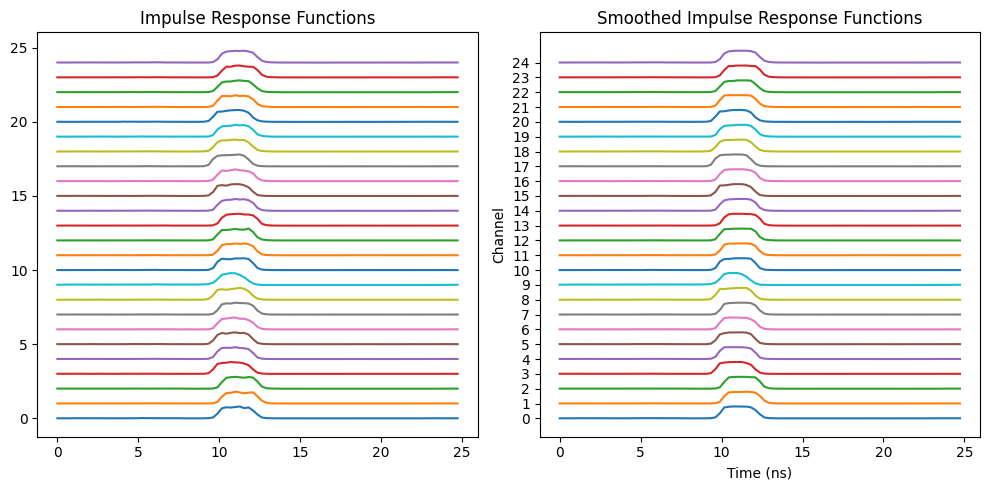

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for n in range(dset.shape[-1]):
    irf_n          = irf_common_delay_realigned[:, n]
    irf_norm       = irf_n / (irf_n.max() + 1e-10)

    irf_n_smoothed      = irf_common_delay_realigned_smoothed[:, n]
    irf_norm_smoothed   = irf_n_smoothed / (irf_n_smoothed.max() + 1e-10)

    ax[0].plot(t, 0.8 * irf_norm + n)
    ax[1].plot(t, 0.8 * irf_norm_smoothed + n)

ax[0].set_title("Impulse Response Functions")
ax[1].set_title("Smoothed Impulse Response Functions")
plt.yticks(np.arange(25))
plt.xlabel("Time (ns)")
plt.ylabel("Channel")
plt.tight_layout()


# FLISM Image Reconstruction

**FLISM** combines the resolution enhancement of ISM with per-pixel lifetime information.
Here we use **s²ISM**, a deconvolution-based method that jointly processes all SPAD channels.

The reconstruction operates on the full 4D dataset `dset` with shape `(y, x, t_bins, channels)`.


## Spatial PSF Simulation

The s²ISM reconstruction requires the **Point Spread Functions (PSFs)** for each SPAD pixel,
encoding the excitation/emission optical transfer functions and the detector array geometry.

**Key parameters to adjust for your system:**
- `na` – Objective numerical aperture
- `exPar.wl` / `emPar.wl` – Excitation and emission wavelengths [nm]
- `n` – Refractive index of the immersion medium
- `grid.pxsizex` – Lateral pixel size [nm] (read from metadata)
- `grid.pxpitch` / `grid.pxdim` – SPAD pixel pitch and size [nm]
- `grid.N` – SPAD pixels per side (5 for the 5×5 array)


In [11]:
exPar = sim.simSettings()
exPar.na         = 1.4    # numerical aperture
exPar.wl         = 488    # excitation wavelength [nm]
exPar.gamma      = 45     # polarisation parameter
exPar.beta       = 90     # polarisation parameter
exPar.n          = 1.5    # refractive index
exPar.mask_sampl = 100    # pupil plane sample points

emPar    = exPar.copy()
emPar.wl = 500            # emission wavelength [nm]

grid           = sim.GridParameters()
grid.Nz        = 2
grid.pxsizex   = pixel_size_x_um * 1e3   # pixel size [nm]
grid.pxsizez   = 720                      # axial spacing [nm]
grid.pxpitch   = 75e3                     # detector array pitch [nm]
grid.pxdim     = 50e3                     # detector pixel size [nm]
grid.N         = 5                        # pixels per axis

psf_spatial, _, _ = est.psf_estimator_from_data(
    dset.sum(-2), exPar, emPar, grid, z_out_of_focus=grid.pxsizez
)


pxsizex       78.28
pxsizez       720.00
Nx            100.00
Nz            2.00
pxpitch       75000.00
pxdim         50000.00
pinhole_shape square
geometry      rect
N             5.00
M             414.00
rotation      2.77
mirroring     1.00
name          
shift         81.47


### Visualise the simulated PSFs

Out-of-focus PSFs


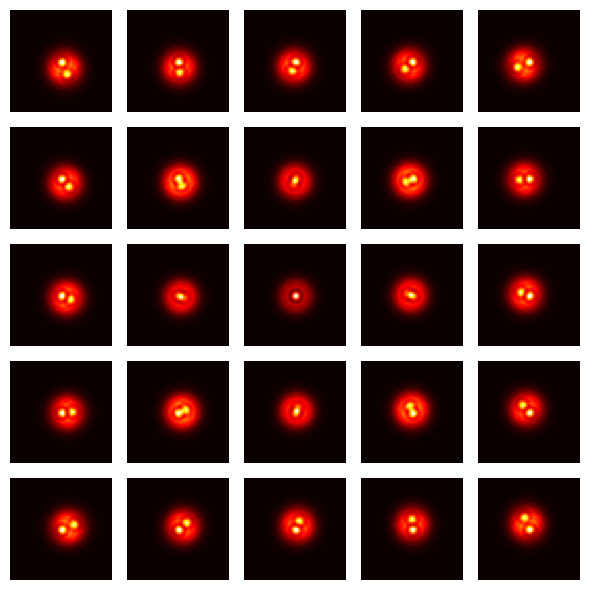

In [12]:
print("Out-of-focus PSFs")
fig_1 = gra.ShowDataset(psf_spatial[0])


In-focus PSFs


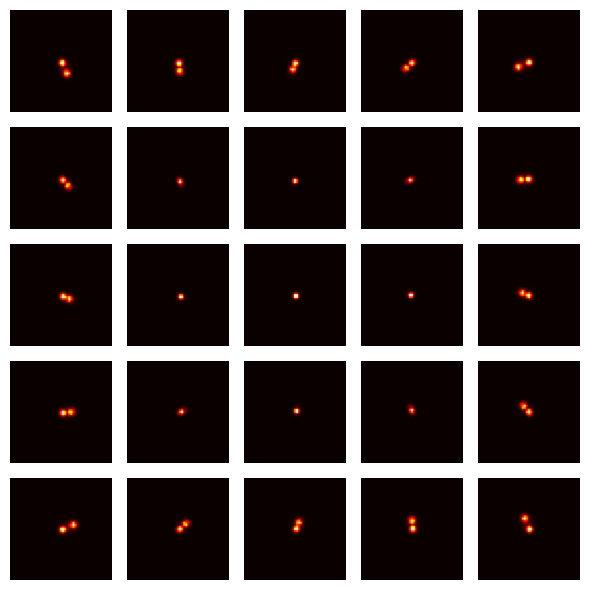

In [13]:
print("In-focus PSFs")
fig_2 = gra.ShowDataset(psf_spatial[1])


## Build the Spatio-Temporal Deconvolution Kernels

`est.combine_psf_irf` forms the outer product of the spatial PSF and the per-channel IRF,
producing a kernel of shape `(Nz, channels, t_bins, y_psf, x_psf)`.

Two kernels are built here:

| Kernel | IRF used | When to use |
|---|---|---|
| `psf_irf` | Measured IRF | Full deconvolution: removes both spatial blur **and** IRF broadening. Phasor correction: rotation by π (see phasor section). |
| `psf_irf_smoothed` | Smoothed IRF | Same as above, but more robust when the raw IRF is noisy. |
| `psf_delta` | Delta function at bin `nbin//2` | Spatial deconvolution only: removes spatial blur but leaves the IRF in the data. Phasor correction: calibration via reference dye phasor. |



> When using `psf_irf` (or `psf_irf_smoothed`) the IRF is already deconvolved from the
> reconstructed traces, so the per-pixel fit uses `irf_summed` purely to account for
> any residual instrumental response. If significant deconvolution artefacts appear,
> switch to `psf_irf_smoothed`.


In [14]:
# Kernel 1: full spatio-temporal kernel with the measured IRF
psf_irf = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned)


In [15]:
# Kernel 2: full spatio-temporal kernel with the smoothed IRF
psf_irf_smoothed = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned_smoothed)


In [16]:
# Kernel 3: spatial-only kernel — the IRF is replaced by a delta function centred at nbin//2.
delta_irf = np.zeros_like(irf_common_delay_realigned)
delta_irf[nbin // 2, :] = 1

psf_delta = est.combine_psf_irf(psf_spatial, delta_irf)

print("psf_delta shape:", psf_delta.shape,
      "  (Nz, channels, t_bins, y_psf, x_psf)")

psf_delta shape: (2, 49, 49, 91, 25)   (Nz, channels, t_bins, y_psf, x_psf)


## s²ISM Reconstruction

`s2.batch_reconstruction` applies Richardson-Lucy deconvolution with the chosen kernel.
The image is processed in overlapping spatial tiles to manage memory.

`batch_reconstruction` with `psf_delta` removes the spatial PSF from each time bin
independently. The output `s2_flism` (shape `(y, x, t_bins)`) contains the spatially
deconvolved decay traces with the IRF broadening still present.


**Parameters to adjust:**
- `batch_size` – Spatial tile size `[rows, cols]`. Reduce if you run out of memory.
- `overlap` – Tile overlap in pixels. Must exceed the PSF support to avoid stitching artefacts.
- `max_iter` – Richardson-Lucy iterations. More iterations sharpen the result but amplify noise.
- `process` – `'gpu'` (recommended if CUDA is available) or `'cpu'`.

The reconstruction returns a list; index `[1]` selects the in-focus plane, shape `(y, x, t_bins)`.


In [17]:
# Full spatio-temporal deconvolution: both the spatial PSF and the IRF are removed.
# The output decay traces are IRF-deconvolved; the per-pixel fit below uses irf_summed
# to account for any residual instrumental response.
s2_rec   = s2.batch_reconstruction(
    dset, psf_delta, batch_size=[301, 301], overlap=40, max_iter=5, process="gpu"
)
s2_flism = s2_rec[1]   # in-focus plane, shape: (y, x, t_bins)

print("s2_flism shape:", s2_flism.shape, "  (y, x, t_bins)")

Batch 1/4


Progress: 6it [00:42,  7.00s/it]                       


Batch 2/4


Progress: 6it [00:33,  5.62s/it]                       


Batch 3/4


Progress: 6it [00:33,  5.54s/it]                       


Batch 4/4


Progress: 6it [00:27,  4.58s/it]                       


s2_flism shape: (512, 512, 91)   (y, x, t_bins)


### Intensity Map

Sum the reconstructed decay traces over the time axis to produce a conventional intensity image.


Text(0.5, 1.0, 's$^2$ISM intensity')

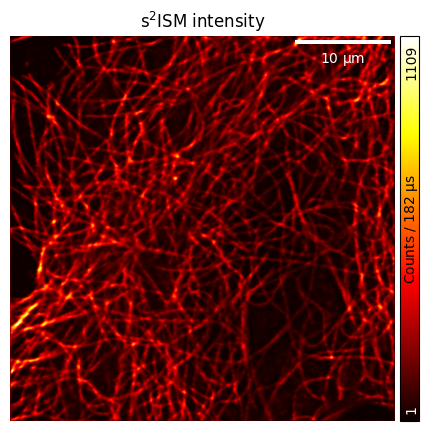

In [18]:
intensity_map = s2_flism.sum(-1)

fig, ax = plt.subplots(figsize=(15, 5))
gra.ShowImg(intensity_map, pixel_size_x_um, pxdwelltime, fig=fig, ax=ax)
ax.set_title(r"s$^2$ISM intensity")


### Temporal Trace Comparison

Compare the spatially integrated decay of the central SPAD channel before and after
reconstruction, alongside the IRF.
The reconstructed trace should not be broader than the raw data; the IRF peak
should still be visible (IRF was *not* deconvolved).


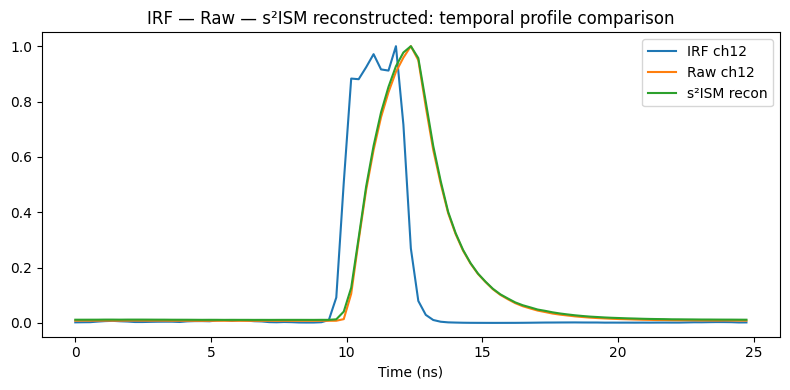

In [19]:
ch = 12   # SPAD channel to inspect (12 = central pixel of the 5×5 array)

irf_ch   = irf_common_delay_realigned[:, ch]
raw_ch   = dset[:, :, :, ch].sum(axis=(0, 1))   # sum over x, y
recon_ch = s2_flism.sum(axis=(0, 1))             # s2_flism has no channel axis

def norm(x):
    return x / x.max()

plt.figure(figsize=(8, 4))
plt.plot(t, norm(irf_ch),   label="IRF ch12")
plt.plot(t, norm(raw_ch),   label="Raw ch12")
plt.plot(t, norm(recon_ch), label=r"s²ISM recon")
plt.xlabel("Time (ns)")
plt.legend()
plt.title(r"IRF — Raw — s²ISM reconstructed: temporal profile comparison")
plt.tight_layout()


# Lifetime Analysis — Per-Pixel Exponential Fit

The reconstructed 3D array `s2_flism` (shape `(y, x, t_bins)`) is used as input for
per-pixel fitting of an IRF-convolved mono-exponential model:

$$I(t) = C \cdot (\text{IRF} * e^{-t/\tau})(t + \Delta t)$$

This is because the reconstruction used `psf_delta`: the IRF is still present
in the decay traces and must be included in the fit model.

`irf_summed` (the channel-aligned, summed IRF) is passed as the instrument response.
`Alignment.perform_fit_data` fits three free parameters per pixel: the lifetime **τ**,
the IRF shift **ΔT**, and the amplitude **C**.  
`Alignment.generate_fit_maps` parallelises this fit over all pixels using `n_jobs=-1`.


## Preview — Single-Pixel Fit

Fit the central pixel of the reconstructed image as a sanity check before running the
full per-pixel loop.


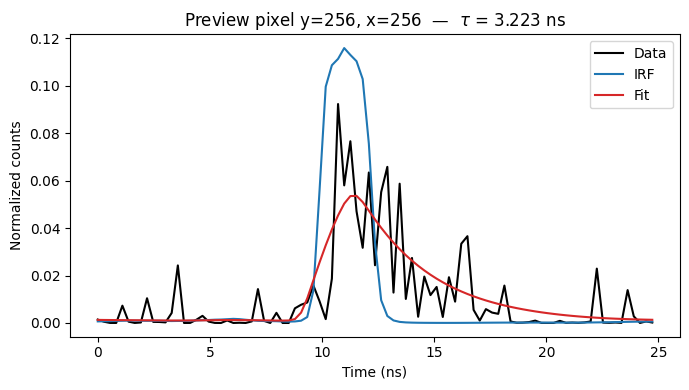

Fit result: {'C': 1.0, 'dT': -3.5005153811160414, 'dT_ns': -0.9616800497571544, 'tau': 3.223339311802091, 'params': {'C': 1.0, 'dT': -3.5005153811160414, 'tau': 3.223339311802091}, 'parameter_names': ['C', 'dT', 'tau'], 'param_names': ['C', 'dT', 'tau'], 'param_values': array([ 1.        , -3.50051538,  3.22333931]), 'param_errors': array([       nan, 1.04520099, 0.65999484]), 'fit': array([0.0013039 , 0.00127105, 0.00124592, 0.00122379, 0.00120177,
       0.00117957, 0.00115848, 0.00113988, 0.00112003, 0.00109692,
       0.00107553, 0.00105747, 0.00104452, 0.00104129, 0.001048  ,
       0.00106188, 0.00108302, 0.00111053, 0.00114416, 0.00118691,
       0.00122746, 0.00124905, 0.00124912, 0.00123095, 0.00120144,
       0.00116932, 0.00113652, 0.00109972, 0.00105902, 0.00102244,
       0.00100452, 0.0010642 , 0.00164198, 0.0043604 , 0.010367  ,
       0.01803349, 0.02555184, 0.03275158, 0.03943107, 0.04533832,
       0.05034676, 0.0535238 , 0.05361683, 0.05100645, 0.0473519 ,
       0.0

In [20]:
preview_y = s2_flism.shape[0] // 2
preview_x = s2_flism.shape[1] // 2
preview_hist = s2_flism[preview_y, preview_x, :]

preview_result, preview_cov = Alignment.perform_fit_data(
    t=t,
    data=preview_hist,
    irf=irf_summed,
    period=laser_period_ns,
    initial_tau=FIT_INITIAL_TAU,
    initial_dT=FIT_INITIAL_dT,
    initial_C=FIT_INITIAL_C,
    mode=FIT_MODE_PIXEL,
    fit_type=FIT_TYPE_PIXEL,
    force_C_normalized=True,
)

fit_preview = Alignment.fit_model_data(
    t,
    preview_result["C"],
    preview_result["dT"],
    preview_result["tau"],
    irf=irf_summed,
    period=laser_period_ns,
    mode=FIT_MODE_PIXEL,
)
fit_preview = Alignment.to_numpy_1d(fit_preview, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, preview_hist / preview_hist.sum(), label="Data",  color="black")
ax.plot(t, irf_summed   / irf_summed.sum(),   label="IRF",   color="tab:blue")
ax.plot(t, fit_preview  / fit_preview.sum(),  label="Fit",   color="tab:red")
#ax.set_yscale("log")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Normalized counts")
ax.set_title(
    f"Preview pixel y={preview_y}, x={preview_x}  —  "
    r"$\tau$ = " + f"{preview_result['tau']:.3f} ns"
)
ax.legend()
plt.tight_layout()
plt.show()

print("Fit result:", preview_result)


## Generate Per-Pixel Fit Maps

`Alignment.generate_fit_maps` iterates over every pixel of `s2_flism`, fits the
IRF-convolved mono-exponential model, and returns a dictionary of parameter maps
(`tau`, `dT`, `C`, `chi2`, …).


In [21]:
if not hasattr(Alignment, "generate_fit_maps"):
    raise RuntimeError(
        "The loaded brighteyes_mcs_file.alignment module does not expose "
        "'generate_fit_maps'. Rerun the first import cell or restart the kernel."
    )

fit_maps = Alignment.generate_fit_maps(
    data=s2_flism,
    irf=irf_summed,
    t=t,
    period=laser_period_ns,
    initial_tau=FIT_INITIAL_TAU,
    initial_dT=FIT_INITIAL_dT,
    initial_C=FIT_INITIAL_C,
    mode=FIT_MODE_PIXEL,
    fit_type=FIT_TYPE_PIXEL,
    force_C_normalized=True,
    n_jobs=-1,
)

fit_stack, fit_stack_names = Alignment.fit_maps_to_stack(fit_maps)
print("fit_stack shape :", fit_stack.shape)
print("fit_stack layers:", fit_stack_names)


Fitting pixel chunks:   0%|          | 0/288 [00:00<?, ?it/s]

fit_stack shape : (6, 512, 512)
fit_stack layers: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


## Visualise Lifetime Maps


**Visualisation**
- `THRESHOLD` – Intensity mask: pixels below `THRESHOLD × max(intensity)` are excluded.
- `LIFETIME_BOUNDS` – `[min_ns, max_ns]` colour scale for the lifetime maps.

In [22]:
# ── Visualisation ─────────────────────────────────────────────────────────

tau       = fit_maps["tau"]
intensity = s2_flism.sum(axis=-1)   # intensity from the reconstructed data

thresholded_tau, thresholded_intensity, lifetime_mask = graph.threshold_lifetime_map(
    tau,
    intensity=intensity,
    threshold=THRESHOLD,
)

print("Finite-tau pixels     :", np.count_nonzero(np.isfinite(tau)))
print("After-threshold pixels:", thresholded_tau.size)


Finite-tau pixels     : 262144
After-threshold pixels: 177011


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

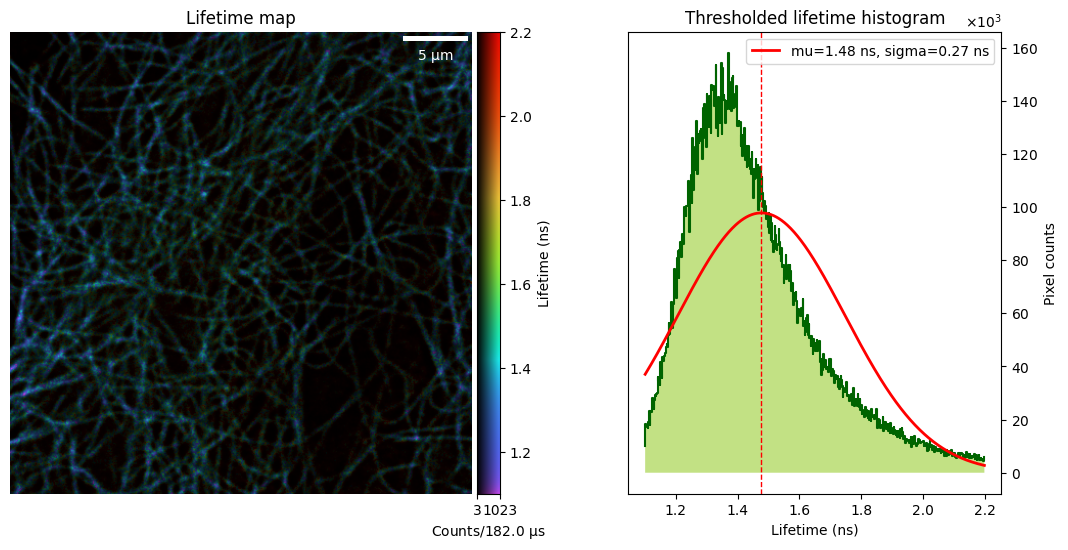

In [23]:
graph.plot_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=LIFETIME_BOUNDS,
    crop=30,
    threshold=THRESHOLD,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

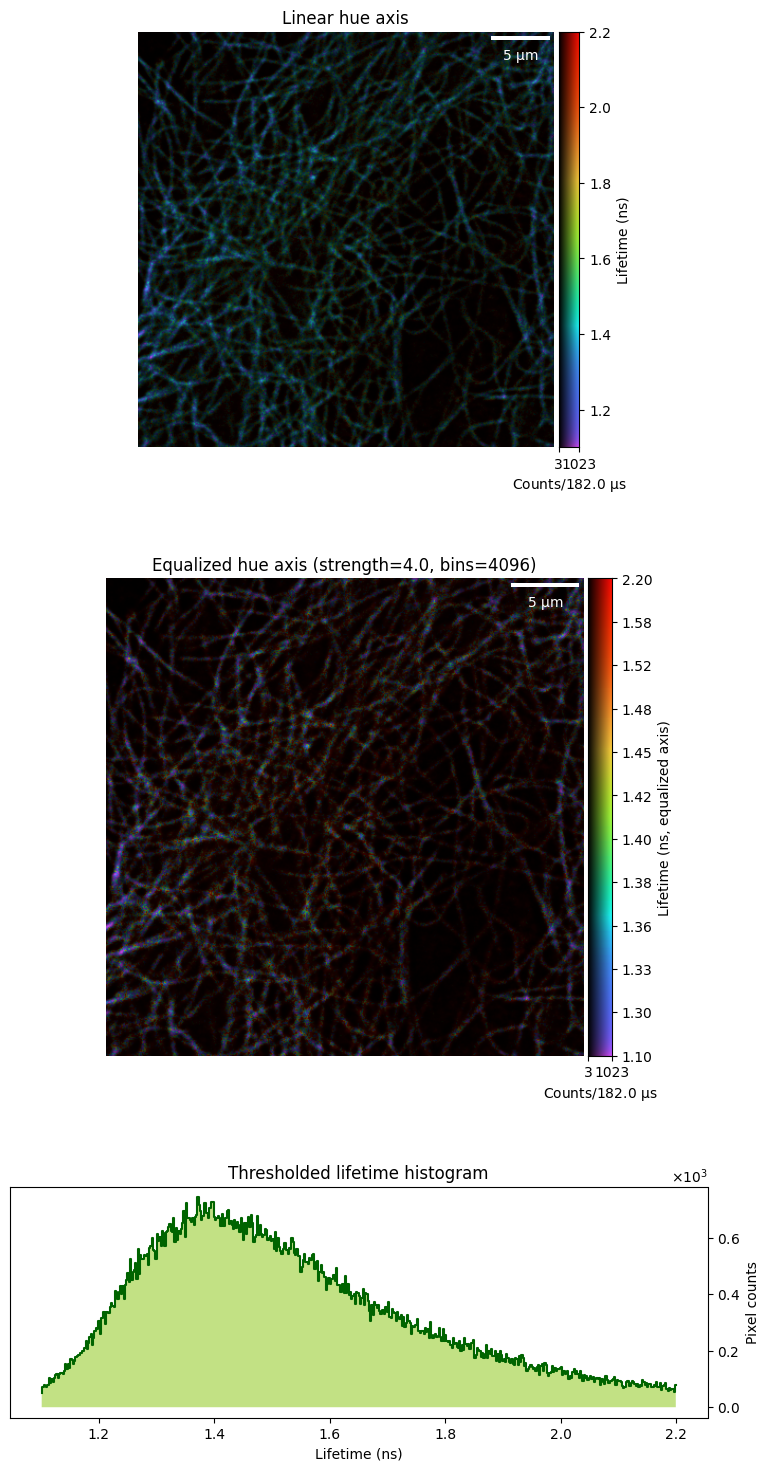

In [24]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity,
    lifetime=tau,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=LIFETIME_BOUNDS,
    crop=30,
    threshold=THRESHOLD,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)


## Optional Export

Set `EXPORT_PATH` to a valid `.h5` path to save the fit results, intensity map,
reconstructed data and IRF. Leave as `None` to skip.


In [28]:
if EXPORT_PATH is not None:
    common_attrs = {
        "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz,
        "laser_period_ns": laser_period_ns,
    }
    target_path, output_run_id = write_h5_output_run(
        FILE_WITH_CALIBRATION,
        "s2ism",
        [
            H5OutputProduct("decay", s2_flism, attrs={**common_attrs, "data_role": "s2ism_reconstructed_decay", "axis_order": "y,x,time_bin"}),
            H5OutputProduct("intensity", intensity, attrs={**common_attrs, "data_role": "s2ism_integrated_intensity", "axis_order": "y,x"}),
            H5OutputProduct("decay_sum", data_summed, attrs={**common_attrs, "data_role": "channel_summed_decay", "axis_order": "y,x,time_bin"}),
            H5OutputProduct("irf", irf_summed, attrs={**common_attrs, "data_role": "channel_summed_irf", "axis_order": "time_bin"}),
        ],
        mode="copy",
        output_path=EXPORT_PATH,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="s2ISM reconstruction",
        algorithm_name="s2.batch_reconstruction",
        parameters={
            "kernel": "psf_delta",
            "batch_size": [301, 301],
            "overlap": 40,
            "max_iter": 5,
            "process": "gpu",
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": s2_flism.shape[0],
            "output_nx": s2_flism.shape[1],
            "output_time_bins": s2_flism.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "s2ism",
        },
        axes=[H5OutputProduct("time_ns", t, attrs={"axis": "time", "units": "ns"})],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x,time_bin",
            "output_data_path": "/output/{run_id}/products/decay",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (EXPORT_PATH = None).")


if EXPORT_PATH is not None:
    fit_source_path = PIPELINE_H5 if "PIPELINE_H5" in globals() else FILE_WITH_CALIBRATION
    fit_mode = "append" if Path(fit_source_path) == Path(EXPORT_PATH) else "copy"
    fit_output_path = None if fit_mode == "append" else EXPORT_PATH
    common_attrs = {
        "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz,
        "laser_period_ns": laser_period_ns,
    }
    products = [
        H5OutputProduct("intensity", intensity, attrs={**common_attrs, "data_role": "integrated_intensity", "axis_order": "y,x"}),
        H5OutputProduct("tau_ns", tau, attrs={**common_attrs, "data_role": "lifetime_tau", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("fit_params", fit_stack, attrs={**common_attrs, "data_role": "fit_parameter_stack", "axis_order": "fit_parameter,y,x", "fit_stack_names_json": fit_stack_names}),
        H5OutputProduct("decay", s2_flism, attrs={**common_attrs, "data_role": "s2ism_reconstructed_decay", "axis_order": "y,x,time_bin"}),
        H5OutputProduct("decay_sum", data_summed, attrs={**common_attrs, "data_role": "channel_summed_decay", "axis_order": "y,x,time_bin"}),
        H5OutputProduct("irf", irf_summed, attrs={**common_attrs, "data_role": "channel_summed_irf", "axis_order": "time_bin"}),
    ]
    for name, arr in fit_maps.items():
        arr = np.asarray(arr)
        if arr.dtype.kind not in "fiu":
            continue
        products.append(
            H5OutputProduct(
                f"fit_maps/{name}",
                arr,
                attrs={**common_attrs, "data_role": f"fit_map_{name}", "axis_order": "y,x"},
            )
        )
    print("Products to export:")
    for product in products:
        arr = np.asarray(product.data)
        print(f"  {product.name}: shape {arr.shape}, dtype {arr.dtype}")

    target_path, output_run_id = write_h5_output_run(
        fit_source_path,
        "s2_lifetime_fit",
        products,
        mode=fit_mode,
        output_path=fit_output_path,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="Lifetime fit",
        algorithm_name="Alignment.generate_fit_maps",
        parameters={
            "fit_initial_tau_ns": FIT_INITIAL_TAU,
            "fit_initial_dT_ns": FIT_INITIAL_dT,
            "fit_initial_C": FIT_INITIAL_C,
            "fit_mode_pixel": FIT_MODE_PIXEL,
            "fit_type_pixel": FIT_TYPE_PIXEL,
            "threshold_fraction": THRESHOLD,
            "fit_stack_names": fit_stack_names,
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": data_summed.shape[0],
            "output_nx": data_summed.shape[1],
            "output_time_bins": data_summed.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "sum_channels_with_skew_correction",
        },
        axes=[H5OutputProduct("time_ns", t, attrs={"axis": "time", "units": "ns"})],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x,time_bin",
            "output_data_path": "/output/{run_id}/products/tau_ns",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (EXPORT_PATH = None).")


Saved s2_lifetime_fit -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_s2ism_with_fit.h5


In [29]:
show_h5_structure_html(EXPORT_PATH)

'<script>\n(function () {\n  // Expand / collapse ALL groups in the widget\n  function h5All(widgetId, open) {\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'details.h5-branch\').forEach(function(d) {\n      d.open = open;\n    });\n  }\n\n  // Expand / collapse all groups at a specific depth inside a widget\n  function h5LevelToggle(widgetId, depth, open, btn) {\n    // Stop the click from toggling the parent <details>\n    if (btn) { btn.closest(\'details\') && (event || window.event) && (event || window.event).stopPropagation(); }\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'li.h5-li-group[data-depth="\' + depth + \'"]\').forEach(function(li) {\n      var det = li.querySelector(\':scope > details.h5-branch\');\n      if (det) det.open = open;\n    });\n  }\n\n  // Expose globally so onclick= attributes work\n  window.h5All = h5All;\n  window.h5LevelToggle = h5LevelTogg